### Imports

Required libraries for statistical analysis.

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

### Data Loading

Loan data loaded from processed parquet file for statistical analysis.

In [3]:
# Data loading
loans = pd.read_parquet('../data/processed/parquet/accepted.parquet')

Quick check on the DataFrame shape.

In [4]:
# Checking the data 
loans.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,mort_acc,pub_rec_bankruptcies,credit_history,acc_to_history_ratio,debt_burden_ratio,is_default,is_high_dti,is_high_util,is_high_risk_grade,is_unverified
0,32000.0,60,10.49,687.65,B,B3,Public Service,10,MORTGAGE,120000.0,...,2.0,0.0,33.34,1.26,0.07,0,0,0,0,0
1,9600.0,36,12.99,323.42,C,C1,Teacher,10,RENT,21900.0,...,0.0,1.0,13.08,1.53,0.18,0,0,0,0,0
2,4000.0,36,6.68,122.93,A,A3,System Analyst,4,MORTGAGE,83000.0,...,2.0,0.0,11.58,2.16,0.02,0,0,0,0,1
3,6025.0,36,10.91,197.00,B,B4,Admin assistant,10,RENT,52000.0,...,0.0,0.0,12.50,2.00,0.05,0,0,0,0,1
4,25000.0,60,26.30,752.96,E,E5,Coordinator,10,OWN,65000.0,...,0.0,0.0,18.59,1.78,0.14,0,1,0,1,0


### Helper Functions

Definition of three utility functions.

The `clean_numeric_data` function removes inf/nan values from specified columns.

In [5]:
# Remove inf/nan values from specified columns
def clean_numeric_data(df, columns):
    return df[columns].replace([np.inf, -np.inf], np.nan).dropna()

The `format_default_rate` function converts default rates to percentage format.

In [6]:
# Convert default rate to percentage and format
def format_default_rate(rate):
    return (rate * 100).round(4)

The `print_analysis_results` function standardizes output format for analysis results.

In [7]:
# Standard format for printing results
def print_analysis_results(title, analysis):
    print(f"\n{title}")
    print(analysis)

### Portfolio Risk Overview

The `analyze_default_rates` function performs segmented risk analysis:
- Calculates default rates and loan counts by segment
- Computes total loan amounts
- Performs chi-square tests for statistical significance
- Applies to key segments: grade, home ownership, and term

In [8]:
# Default rates analysis
def analyze_default_rates(df, segment_col):
    # Calculate default rates and loan counts
    analysis = df.groupby(segment_col).agg({
        'is_default': ['count', 'mean'],
        'loan_amnt': 'sum'
    }).round(4)
    
    # Rename columns
    analysis.columns = ['loan_count', 'default_rate', 'total_loan_amount']
    analysis['default_rate'] = analysis['default_rate'] * 100
    
    # Add chi-square test
    contingency = pd.crosstab(df[segment_col], df['is_default'])
    chi2, p_value = stats.chi2_contingency(contingency)[:2]
    
    print(f"\nDefault Rate Analysis by {segment_col}")
    print(analysis)
    print(f"\nChi-square p-value: {p_value:.4f}")
    return analysis

Performing the analysis.

In [9]:
# Analyze key segments
segments = ['grade', 'home_ownership', 'term']
for segment in segments:
    analyze_default_rates(loans, segment)


Default Rate Analysis by grade
       loan_count  default_rate  total_loan_amount
grade                                             
A          382740          3.66       5.587387e+09
B          587472          8.81       8.330151e+09
C          575193         14.59       8.653195e+09
D          287151         20.63       4.511159e+09
E          119939         28.51       2.093486e+09
F           36763         36.70       7.020722e+08
G           10742         40.43       2.185852e+08

Chi-square p-value: 0.0000

Default Rate Analysis by home_ownership
                loan_count  default_rate  total_loan_amount
home_ownership                                             
ANY                    888          7.43       1.178060e+07
MORTGAGE            983941         11.35       1.642170e+10
NONE                    46         17.39       6.248250e+05
OTHER                  157         22.93       1.670650e+06
OWN                 223695         13.09       3.216923e+09
RENT                

### Demographic and Geographic Patterns

Definition and usage of three analysis functions.

The `analyze_geographic_patterns` function:
- Aggregates loan metrics by state
- Calculates approval disparities between states
- Identifies geographic lending patterns

In [10]:
# Geographic analysis
def analyze_geographic_patterns(df):
    geo_analysis = df.groupby('addr_state').agg({
        'loan_amnt': ['count', 'mean', 'sum'],
        'int_rate': 'mean',
        'is_default': 'mean'
    }).round(4)
    
    # Calculate approval disparities
    state_metrics = pd.DataFrame()
    for state in df['addr_state'].unique():
        state_data = df[df['addr_state'] == state]
        others = df[df['addr_state'] != state]
        
        state_approval_rate = 1 - state_data['is_default'].mean()
        other_approval_rate = 1 - others['is_default'].mean()
        disparity_ratio = state_approval_rate / other_approval_rate
        
        state_metrics.loc[state, 'disparity_ratio'] = disparity_ratio
    
    return pd.concat([geo_analysis, state_metrics], axis=1)

Performing the analysis.

In [11]:
# Analyze geographic patterns
geo_patterns = analyze_geographic_patterns(loans)
print("\nGeographic Lending Patterns:")
print(geo_patterns.sort_values(('is_default', 'mean'), ascending=False).head())


Geographic Lending Patterns:
    (loan_amnt, count)  (loan_amnt, mean)  (loan_amnt, sum)  (int_rate, mean)  \
IA                13.0          8351.9231          108575.0           12.4877   
AL             24028.0         14677.3369       352667050.0           13.5597   
MS             11192.0         14722.6211       164775575.0           13.4568   
AR             15146.0         14076.7447       213206375.0           13.3569   
OK             18213.0         15059.7170       274282625.0           13.2391   

    (is_default, mean)  disparity_ratio  
IA              0.2308         0.884649  
AL              0.1568         0.969341  
MS              0.1568         0.969543  
AR              0.1540         0.972697  
OK              0.1534         0.973384  


The `analyze_income_patterns` function:
- Segments borrowers into income quintiles
- Analyzes loan characteristics across income bands
- Performs ANOVA tests on interest rates

In [12]:
# Income level analysis
def analyze_income_patterns(df):
    df['income_band'] = pd.qcut(df['annual_inc'], 5, 
                               labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    
    income_analysis = df.groupby('income_band', observed=False).agg({
        'loan_amnt': ['count', 'mean'],
        'int_rate': 'mean',
        'is_default': 'mean'
    }).round(4)
    
    f_stat, p_value = stats.f_oneway(*[group['int_rate'].values 
                                      for name, group in df.groupby('income_band', observed=False)])
    
    print("\nIncome Level Analysis:")
    print(income_analysis)
    print(f"\nANOVA test p-value for interest rates: {p_value:.4f}")
    return income_analysis

Performing the analysis.

In [13]:
income_patterns = analyze_income_patterns(loans)


Income Level Analysis:
            loan_amnt             int_rate is_default
                count        mean     mean       mean
income_band                                          
Very Low       404751   9196.4287  13.8788     0.1535
Low            404653  12290.6287  13.4362     0.1437
Medium         422882  14817.0783  13.0994     0.1339
High           372041  17629.9790  12.7758     0.1199
Very High      395673  21672.8981  12.2229     0.0996

ANOVA test p-value for interest rates: 0.0000


The `analyze_ownership_patterns` function:
- Examines lending patterns by home ownership status
- Calculates disparate impact ratios

In [14]:
# Home ownership analysis
def analyze_ownership_patterns(df):
    ownership_analysis = df.groupby('home_ownership').agg({
        'loan_amnt': ['count', 'mean'],
        'int_rate': 'mean',
        'is_default': 'mean'
    }).round(4)
    
    baseline_rate = df[df['home_ownership'] == 'OWN']['is_default'].mean()
    ownership_analysis['disparate_impact'] = ownership_analysis[('is_default', 'mean')] / baseline_rate
    
    return ownership_analysis

Performing the analysis.

In [15]:
ownership_patterns = analyze_ownership_patterns(loans)
print("\nHome Ownership Analysis:")
print(ownership_patterns)


Home Ownership Analysis:
               loan_amnt             int_rate is_default disparate_impact
                   count        mean     mean       mean                 
home_ownership                                                           
ANY                  888  13266.4414  12.8519     0.0743         0.567622
MORTGAGE          983941  16689.7170  12.7471     0.1135         0.867094
NONE                  46  13583.1522  14.4893     0.1739         1.328526
OTHER                157  10641.0828  13.5290     0.2293         1.751759
OWN               223695  14380.8453  13.1167     0.1309         1.000023
RENT              791273  13198.1487  13.5131     0.1515         1.157399


### Detailed Risk Assessment

Definition and usage of three analysis functions.

The `create_risk_scorecard` function:
- Creates binned risk categories
- Calculates Weight of Evidence (WoE) and Information Value (IV)
- Generates risk metrics for key factors

In [16]:
# Risk scorecard development
def create_risk_scorecard(df, feature, bins, labels=None):
    # Create bins
    df[f'{feature}_band'] = pd.qcut(df[feature], bins, labels=labels)
    
    # Calculate metrics
    scorecard = df.groupby(f'{feature}_band', observed=True).agg({
        'is_default': ['count', 'mean'],
        'loan_amnt': ['mean', 'sum']
    }).round(4)
    
    # Calculate WoE and IV
    good = df[df['is_default'] == 0][f'{feature}_band'].value_counts()
    bad = df[df['is_default'] == 1][f'{feature}_band'].value_counts()
    
    woe = np.log((good/good.sum())/(bad/bad.sum()))
    iv = ((good/good.sum())-(bad/bad.sum())) * woe
    
    print(f"\nRisk Scorecard for {feature}")
    print(f"Information Value: {iv.sum():.4f}")
    return scorecard

Performing the analysis.

In [17]:
# Define risk factors and bins
risk_factors = {
    'dti': 5,
    'credit_history': 5,
    'revol_util': 5
}

# Create scorecards
scorecards = {}
for factor, bins in risk_factors.items():
    scorecards[factor] = create_risk_scorecard(loans, factor, bins)


Risk Scorecard for dti
Information Value: 0.0389

Risk Scorecard for credit_history
Information Value: 0.0117

Risk Scorecard for revol_util
Information Value: 0.0360


The `perform_risk_factor_tests` function:
- Conducts t-tests between default/non-default groups
- Performs logistic regression analysis
- Calculates odds ratios for risk factors

In [18]:
# Risk factor statistical tests
def perform_risk_factor_tests(df, factor):
    # Remove rows with inf or nan values 
    analysis_df = clean_numeric_data(df, [factor, 'is_default'])
    
    # T-test between default and non-default groups
    default_group = analysis_df[analysis_df['is_default'] == 1][factor]
    non_default_group = analysis_df[analysis_df['is_default'] == 0][factor]
    t_stat, p_value = stats.ttest_ind(default_group, non_default_group)
    
    # Logistic regression
    X = sm.add_constant(analysis_df[factor])
    y = analysis_df['is_default']
    model = sm.Logit(y, X)
    results = model.fit(disp=0)
    
    print(f"\nStatistical Analysis for {factor}")
    print(f"Sample size after cleaning: {len(analysis_df)}")
    print(f"T-test p-value: {p_value:.4f}")
    print(f"Logistic Regression p-value: {results.pvalues.iloc[1]:.4f}")
    print(f"Odds Ratio: {np.exp(results.params.iloc[1]):.4f}")

Performing the analysis.

In [19]:
# Test risk factors
risk_factors = ['dti', 'credit_history', 'revol_util', 'acc_to_history_ratio']
for factor in risk_factors:
    perform_risk_factor_tests(loans, factor)


Statistical Analysis for dti
Sample size after cleaning: 2000000
T-test p-value: 0.0000
Logistic Regression p-value: 0.0000
Odds Ratio: 1.0211

Statistical Analysis for credit_history
Sample size after cleaning: 1999948
T-test p-value: 0.0000
Logistic Regression p-value: 0.0000
Odds Ratio: 0.9871

Statistical Analysis for revol_util
Sample size after cleaning: 2000000
T-test p-value: 0.0000
Logistic Regression p-value: 0.0000
Odds Ratio: 1.0075

Statistical Analysis for acc_to_history_ratio
Sample size after cleaning: 1999948
T-test p-value: 0.0000
Logistic Regression p-value: 0.0000
Odds Ratio: 1.1380


### Visualization Summary

Created a 2x2 dashboard showing:
1. Loan amount distribution by income level
2. Interest rates by home ownership
3. Default rates by state
4. Interest rate distribution by home ownership status

/tmp/ipykernel_37885/3918301585.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45)


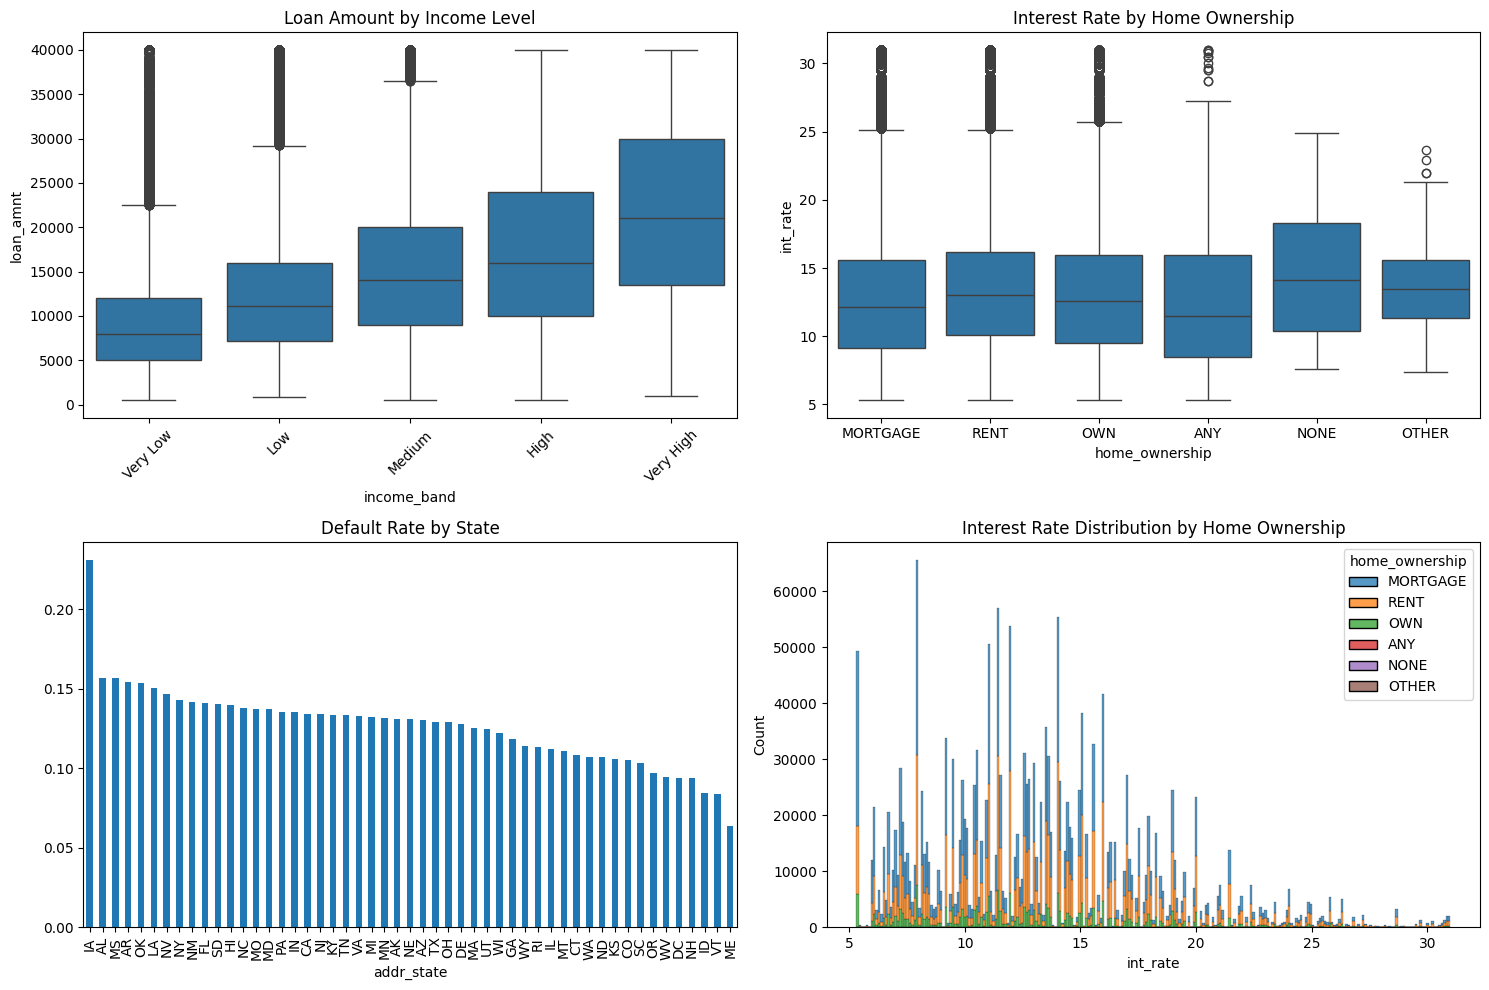

In [20]:
# Visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loan amount distribution by income band
sns.boxplot(data=loans, x='income_band', y='loan_amnt', ax=axes[0,0])
#axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_title('Loan Amount by Income Level')

# Interest rate by home ownership
sns.boxplot(data=loans, x='home_ownership', y='int_rate', ax=axes[0,1])
axes[0,1].set_title('Interest Rate by Home Ownership')

# Default rate by state
state_default_rates = loans.groupby('addr_state')['is_default'].mean().sort_values(ascending=False)
state_default_rates.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Default Rate by State')
axes[1,0].tick_params(axis='x', rotation=90)

# Interest rate distribution by home ownership
sns.histplot(data=loans, x='int_rate', hue='home_ownership', multiple="stack", ax=axes[1,1])
axes[1,1].set_title('Interest Rate Distribution by Home Ownership')

plt.tight_layout()
plt.show()

### Conclusion

The comprehensive statistical analysis reveals significant patterns in loan performance and risk factors:

**Grade-Based Risk Stratification**
- Loan grades demonstrate strong predictive power for defaults (p < 0.0001)
- Clear risk progression from Grade A (3.66% defaults) to Grade G (40.43% defaults)
- Default rates approximately double between consecutive grades
- Risk-based pricing evident in portfolio allocation, with middle grades (B-C) having highest loan volumes
- Portfolio concentrated in grades B-C (1.16M loans), balancing risk and return between low-risk A (383K) and high-risk F-G (48K)

**Borrower Characteristics**
- Home ownership significantly influences default risk (p < 0.0001)
  * Mortgage holders show lowest risk among major categories (11.35%)
  * Renters exhibit elevated risk (15.15%)
  * Small segments (OTHER, NONE) show highest risk but low volume
- Income levels demonstrate strong inverse relationship with defaults
  * Very High income segment: 9.96% default rate
  * Very Low income segment: 15.35% default rate
  * ANOVA confirms significant interest rate differences across income bands (p < 0.0001)

**Loan Structure Impact**
- Term length significantly affects default probability (p < 0.0001)
  * 60-month loans show 60% higher default rate (17.82%) vs 36-month loans (11.12%)

**Geographic Patterns**
- Significant state-level variations in default rates
- Top 5 highest-risk states show default rates >15%
- Geographic disparities in approval ratios range from 0.88 to 0.97

**Risk Factor Analysis**
- All analyzed risk factors show statistical significance (p < 0.0001)
- Account-to-history ratio shows strongest effect (OR = 1.138)
- DTI demonstrates modest but significant impact (OR = 1.021)
- Credit history shows slight protective effect (OR = 0.987)
- Information Values suggest moderate predictive power:
  * DTI (IV = 0.0389)
  * Revolving utilization (IV = 0.0360)
  * Credit history (IV = 0.0117)

These findings support a multi-factor approach to risk assessment, with loan grade, term length, and income level serving as primary risk indicators. The analysis suggests opportunities for geographic risk adjustment and targeted underwriting based on home ownership status.